### Anomaly Informed Remaining Useful Life Estimation (AIRULE) Using Hybrid LSTM models (June 2024)

available at: https://doi.org/10.1016/j.mex.2024.102555

### Initial Interpretation
- As a machine reaches failure, its RUL diminishes lineraly.
- However, estimating RUL prior the failure region is difficult

- This system not only informs the inception of anomalies but also forecasts the remaining operational life of the machinery.


- They use feature ranking and selection techniques
- They use unsupervised clustering algorithms for anomaly trend analysis & 

- Clip dataset an first signs of anomalies (not the entire dataset)

- RUL Regressor training & RUL prediction at the end

![AIRULE Methodology](./media/AIRULE_Method.png)

<br>
<hr>

### Informed Interpretation
Two parts (Methods essentialities):
1. Anomaly detection & anomaly onset identification
    Find when degredation begins (unsupervised)
2. Anomaly-triggered RUL estimation
    Once degredation begins (anomaly onset above), activate supervised model to predict RUL on only the degrading portion of the data

Super adaptable & versatile (use with any vibration sensor dataset!)

# Methodology

### Setting Constant Seed
Attempting to keep repoduction of AutoEncoder consistent (for the sake of setting up really)

In [15]:
import numpy as np
import tensorflow as tf
import random
#import os

SEED = 23
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)


### Locating Dataset

In [16]:
import os, sys

DATASET_LOC = "./Datasets/"
NASA_BEARING_DATASET_LOC = DATASET_LOC + "NASABearing/"
DEBUG = True

# For all sets_directories (not files) in dataset dir - Path.join is concatenates full path str lit to directory
sets_directories = [os.path.join(NASA_BEARING_DATASET_LOC, d)+f"/{d}/" for d in  os.listdir(NASA_BEARING_DATASET_LOC) if os.path.isdir(os.path.join(NASA_BEARING_DATASET_LOC, d))]

## Select Dataset ##
DATASET_DIR_INUSE = sets_directories[0]

if DEBUG:
    print("Available sets in Dataset are:")
    for i, dir in enumerate(sets_directories):
        print(f"[{i}] {dir}")
    # Using set/run 2
    print(f"Using set: {DATASET_DIR_INUSE}")


print(f"Count of bursts/files: {len(os.listdir(DATASET_DIR_INUSE))}")

Available sets in Dataset are:
[0] ./Datasets/NASABearing/1st_test/1st_test/
Using set: ./Datasets/NASABearing/1st_test/1st_test/
Count of bursts/files: 2156


### Feature Extraction - Features are scalars used during learning stages (You don't use raw data)

11 Features Total (so far (12/01 14:58))

AIRULE paper proposes:
ptp, std, crest factor, rms, skewness, kurtosis,
Spectral Centriod, spectral entropy, frequency peak, Spectral spread (spectral std), 

<ins>Time Domain</ins>

- RMS
- Std
- Peak-to-Peak (PTP)
- Kurtosis
- Skewness
- Crest factor

<ins>Frequency Domain</ins>

- Spectral bandwidth (spread of frequencies)
- spectral centroid (center of mass of spectrum)
- Spectral total energy (overall vibration energy)
- Spectral Entropy
- Peak frequency (dominant vibration frequency)

Helpful source - Check out start of methodology:
https://wes.copernicus.org/articles/10/2841/2025/wes-10-2841-2025.html

In [17]:
import numpy as np
#temp test
x = [1,2,3,5, 10]
print(np.ptp(x))
max(x)-min(x)

y = [-1,-6, 3, 9]
np.abs(y)

x = np.random.randn(20480)
X = np.fft.rfft(x)


# Magnitude Spectrum consists of Absolute (positives) where m_n >= 0
M = np.abs(X)


P_n = M / np.sum(M) 
F = len(P_n)
# Prevent NAN issue - log(0 or -P_n) = undefined (NaN) - This occurs becaues the first value in P_n is set to 0
P_n_safe = P_n[P_n > 0]
  
SEN = -np.sum(P_n_safe * np.log2(P_n_safe)) / np.log2(F)
SEN


9


0.9848666677123746

In [18]:
import pandas as pd
import numpy as np
import scipy.stats as stats

# Must check dataset in use - check num rows in  one burst
DATAPOINTS_PER_FILE = 20480
SAMPLE_RATE = 20000 # 20 kHz


time_step = 1 / SAMPLE_RATE
# np.arange returns arr of evenly spaced values within the given interval 
# so a float timestamp that can be used in timedelta at the 
# files starting point (such 2004.02.19.06.22.39) - there are 20480 
# datapoints which need time indexing/stamping
# Kind reminds me of pandas resample method but for relative (not actual) time in a given time period
timestamps = np.arange(DATAPOINTS_PER_FILE) * time_step
#print(timestamps)

features = [
    # Time Domain Features
    "rms",
    "std",
    "ptp",
    "kurtosis",
    "skew",
    "crest",

    # Frequency Domain Features
    "spectral_centroid",
    "spectral_bandwidth",
    "spectral_total",
    "spectral_entropy",
    #"frequency_peak"
]

df = pd.DataFrame(columns=features) #columns=["b1", "b2", "b3", "b4"])


## ---- Time Domain Features
# Feature	Meaning
# RMS	Overall vibration energy
# Std	Signal spread
# Mean	Should be ~0 (after de-meaning)
# Peak-to-peak	Max impulse size
# Kurtosis	Impulsiveness (very important)
# Skewness	Asymmetry
# Crest factor	Peak / RMS
## ---- Calcuation
# Where x the 20480 readings in a burst for the deterioted bearing (b1)
# Time Domain Features = {
#     "rms": np.sqrt(np.mean(x**2)),
#     "std": np.std(x),
#     "ptp": np.ptp(x),
#     "kurtosis": stats.kurtosis(x, fisher=False),
#     "skew": stats.skew(x),
#     "crest": np.max(np.abs(x)) / np.sqrt(np.mean(x**2))
# }
# Frequency Domain Features = {
#     ""
# }


BEARINGS_COUNT:int # not implemented sensor-fusion on single bearing (point) yet
CSV_DELIM:str = "\t"
# Parse & understand CSV files in dataset 
with open(DATASET_DIR_INUSE+os.listdir(DATASET_DIR_INUSE)[0]) as file:
    line = file.readline()
    NUMERICAL_CHARS = [".", "-", "+"] # Doesnt count unary values, decimal points as delimeters
    for char in line:
        if not char.isnumeric() and char not in NUMERICAL_CHARS:
            print(f"Suspected Delimiter: '{char}'")
            CSV_DELIM = char
            break
    cols = line.count(CSV_DELIM) + 1
    print(f"Bearings (coloums) found: {cols}")
    BEARINGS_COUNT = cols


temp_index = 0

bursts_read = 0 # For understanding Live implementation
MAX_BURSTS = 19000

for file_reading_interval in os.listdir(DATASET_DIR_INUSE):
    # Each iteration is a burst (file contains one burst)
    if bursts_read == MAX_BURSTS:
        break
    bursts_read += 1


    # print(file_reading_interval)
    time_interval_df = pd.read_csv(
        DATASET_DIR_INUSE+file_reading_interval, 
        delimiter=CSV_DELIM, 
        # [b1, b2, ..., bn]
        names=["b"+str(i+1) for i in range(BEARINGS_COUNT)], header=None)
    
    start = pd.to_datetime(file_reading_interval, format="%Y.%m.%d.%H.%M.%S")
    time_interval_df.index = start + pd.to_timedelta(timestamps, unit="s")

    # print(f"reading starts at: {time_interval_df.index[0]}")
    # print(f"reading ends at: {time_interval_df.index[-1]}")
    # print(time_interval_df)
    # break

    try:
        """Bearings Readings over this Signal"""
        bearings_readings = time_interval_df["b5"]
    except KeyError as err:
        print("\n[CAUGHT ERROR]: File(s) for set selected doesnt have this many columns?")
        break


    # TIME DOMAIN
    td_features_dict = {}
    
    # Numpy array
    x:list = np.asarray(bearings_readings)
    mu:float = np.mean(x)
    N:int = len(x)

    td_features_dict["id"] = file_reading_interval

    # Features Extraction 
    # Root Mean Square - Overall Energy in Signal
    RMS = np.sqrt(np.sum(x**2) / N)
    td_features_dict["rms"] = RMS # np.sqrt(np.mean(bearings_readings**2))
   

    # Standard Deviation - Spread/Var
    Std = np.sqrt(np.sum((x - mu)**2) / N)
    td_features_dict["std"] = Std # np.std(bearings_readings)
  
    
    # Peak to Peak - Distance from max and min
    Peak_max:float = np.max(x)
    Peak_min:float = np.min(x)
    PTP:float = Peak_max - Peak_min
    td_features_dict["ptp"] = PTP # np.ptp(bearings_readings)

    # Skewness - 3rd Central Moment - Symmetric difference (more prominant on negative or positive side)
    Sk = (np.sum((x-mu)**3)) / ((N-1)*Std**3)
    td_features_dict["skew"] = Sk # stats.skew(bearings_readings)


    # Kurtosis - 4th Central Moment - Determines flatness or peakiness (is the distribution more similar therefore flatter or does it contain some impulsive anomalies therefore peakier)
    Ku = (np.sum((x-mu)**4)) / ((N-1)*Std**4)
    td_features_dict["kurtosis"] = Ku #stats.kurtosis(bearings_readings, fisher=False)  # Fisher (if True) subtracts 3 from result (3 is standardised as normal distribution) so the normal distribution score is then 0.0
   
    # Crest Factor - Early warning sign for Impulsive Behaviour -  Indicates impact incuring within the bearing (contacts between the balls & the raceway track)
    # Takes max (Peak max) over the absolute values of x here: https://www.mdpi.com/2075-1702/5/4/21, the absolute x is not explicit here: https://www.researchgate.net/publication/286318685_Survey_of_condition_indicators_for_condition_monitoring_systems
    Peak_max_abs:float = np.max(np.abs(x))
    CF = Peak_max_abs / RMS
    td_features_dict["crest"] = CF
  




    # FREQUENCY DOMAIN
    fd_features_dict = {}
    # Convert Time-Domain to Frequency-Domain
    # FFT is the Fast Fourier Transform - It is the optimised Discrete Fourier Transform (DFT) 
    fft_b1_burst = np.fft.rfft(list(bearings_readings))
    
    # Magnitude Spectrum consists of Absolute (positives) where m_n >= 0
    M = np.abs(fft_b1_burst)

    frequencies = np.fft.rfftfreq(len(bearings_readings), d=1/DATAPOINTS_PER_FILE) # 1/sample rate per burst (20480)
    # First reading is normally super high (the first value when using the FFT 
    # formular is set to the sum of all the samples in this signal instance - apprently)
    # so set it to 0 to remove this dominance
    M[0] = 0

    # Index is n, n = 1, ... F Mathematically - n = 0, ..., F-1 Computationally
    F = len(frequencies)    

    MSum = np.sum(M) # Use to optimise beloew & bring some of them down to constant time-complexity O(1)

    # Bins in FFT are frequency slots (indicates strength of vibration at that frequency)
    # The readings (20480 rows) becoems: 20480 / 2 + 1 = 10241 frequency bins 


    # - spectral centroid (center of mass of spectrum)
    SC = np.sum(frequencies * M) / MSum
    fd_features_dict["spectral_centroid"] = SC

    # - Spectral bandwidth (spread of frequencies)
    SB = np.sqrt(np.sum(((frequencies - SC) ** 2) * M) / MSum)
    fd_features_dict["spectral_bandwidth"] = SB

    # - Spectral Energy (Total overall vibration energy)
    SE = np.sum(M**2)
    fd_features_dict["spectral_total"] = SE
    
    # NOTE - Using Spectal Entropy brought the triggered anomaly onset period back 2 days for the NASA DS, Set 1 (Earlier Warning!)
    # Spectral Entropy - Measure peakiness over the M spectrum
    # P_n is Probabiltity Distribution - Found in literature typically, & MathWorks examples as P(m) where m is the sample (this fft frequency's bins) :) - n is indicies over our fft samples 
    P_n = M / MSum
  
    # Prevent NAN issue - log(0 or -P_n) = undefined (NaN) - This occurs becaues the first value in P_n is 0 
    P_n_safe = P_n[P_n > 0]
  
    SEN = -np.sum(P_n_safe * np.log2(P_n_safe)) / np.log2(F)
    fd_features_dict["spectral_entropy"] = SEN
    # Spectral entropy came down a tiny amount over the lifetime of the eventually broken bearing.


    # EXTRA (Not mentioned in methodology & not used here)
    
    # - Peak frequency (dominant vibration frequency)
    # In OpenAE, they do the rfftfreq conversion as part of this feature equation. We already compute rfft therefore, 
    # we can just do the following: 
    # np.argmax Finds & Returns the indices of the maximum values along an axis (idx of largest val in M).
    #SPF = frequencies[np.argmax(M)] 
    #fd_features_dict["frequency_peak"] = SPF


    # High Freqs energy ratio (threshold is >5kHz) 
    # - High-frequency energy ratio (Early fault indicator?)
    # THRESHOLD = 5000
    # fd_features_dict["high_frequency_ratio"] = np.sum(M[frequencies > THRESHOLD]**2) / fd_features_dict["spectral_total"] 
    ##########


    features_dict = {**td_features_dict, **fd_features_dict}

   
    df.loc[len(df)] = features_dict

df.index = os.listdir(DATASET_DIR_INUSE)[:bursts_read]
df.index = pd.to_datetime(df.index, format="%Y.%m.%d.%H.%M.%S")


print(df)
print(f"{df.shape} (number of bursts ROW, number of features per burst COL)")

Suspected Delimiter: '	'
Bearings (coloums) found: 8
                          rms       std    ptp   kurtosis      skew  \
2003-10-22 12:06:24  0.128887  0.091461  0.896   3.405605  0.034373   
2003-10-22 12:09:13  0.129562  0.091732  1.059   3.445886  0.001097   
2003-10-22 12:14:13  0.131339  0.091813  0.987   3.389877  0.053074   
2003-10-22 12:19:13  0.131083  0.092385  0.874   3.262121 -0.023655   
2003-10-22 12:24:13  0.131307  0.091932  0.998   3.326354  0.027082   
...                       ...       ...    ...        ...       ...   
2003-11-25 16:07:32  0.275645  0.250236  5.825   7.150947 -0.089561   
2003-11-25 23:13:21  0.496173  0.483099  9.651  14.722133 -0.129055   
2003-11-25 23:19:56  0.531569  0.520574  9.902  14.271444 -0.083701   
2003-11-25 23:29:56  0.474447  0.459749  9.191  12.389192 -0.303940   
2003-11-25 23:39:56  0.593610  0.579418  9.998   8.903110  0.067198   

                         crest  spectral_centroid  spectral_bandwidth  \
2003-10-22 12:06:24  

2003-10-22 12:06:24    0.974984
2003-10-22 12:09:13    0.974828
2003-10-22 12:14:13    0.975272
2003-10-22 12:19:13    0.975027
2003-10-22 12:24:13    0.975280
                         ...   
2003-11-25 16:07:32    0.970580
2003-11-25 23:13:21    0.967167
2003-11-25 23:19:56    0.968123
2003-11-25 23:29:56    0.970938
2003-11-25 23:39:56    0.968646
Name: spectral_entropy, Length: 2156, dtype: float64


<Axes: >

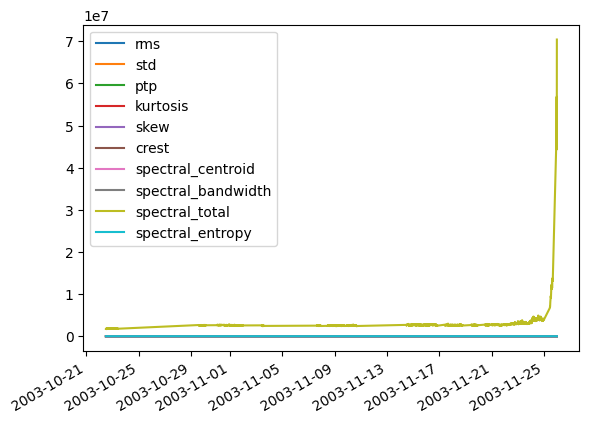

In [26]:
print(df["spectral_entropy"])

df.plot()

## Feature Standardisation (scaling all features to shared scale)
Imperative before using KMeans clustering. otherwise, larger spanning features (spectral energy) will be the dominating feature - all features should be fairly assessed.

Note - This is NOT normalisation. 
- Normalisation brings values to a fixed range (0-1).
- Standardisation brings values to a range where the mean is 0 & std is 1

Both bring the values spread closer, but not the same fundementally.

 

[1]: spectral_total: 68688148.85455401
[2]: spectral_centroid: 435.70719658615235
[3]: spectral_bandwidth: 341.6439900965429
[4]: kurtosis: 71.3597083997114
[5]: crest: 22.537915185213063
[6]: ptp: 9.198
[7]: skew: 3.776054187900959
[8]: std: 0.48889196542640867
[9]: rms: 0.4647228209363563
[10]: spectral_entropy: 0.01071177272096846

Mean=292065.12980146153, Std=1187245.5253857183


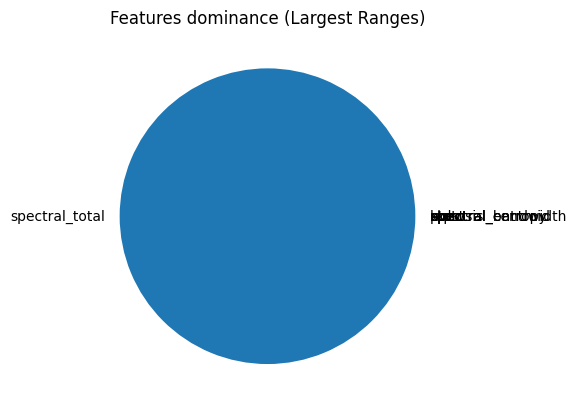

In [27]:
# Why normalise? Some features have larger ranging values (larger changing too) then other featuers.
# Spectral total is a hugely dominating feature
import matplotlib.pyplot as plt

def features_pie(df:pd.DataFrame):
    feature_ranges = []
    for feature in features:
        feature_range = np.max(df[feature]) - np.min(df[feature])
        feature_ranges.append((feature, feature_range))

    feature_ranges.sort(key=lambda feature_tup: feature_tup[1], reverse=True)
    for dominance_ranking, feature_tup in enumerate(feature_ranges):
        print(f"[{dominance_ranking+1}]: {feature_tup[0]}: {feature_tup[1]}")
    
    print(f"\nMean={np.mean(df[features].values)}, Std={np.std(df[features].values)}")

    labels = [f_name for f_name, _ in feature_ranges]
    values = [v for _, v in feature_ranges]

    plt.pie(values, labels=labels)
    plt.title("Features dominance (Largest Ranges)")
    plt.plot()

features_pie(df[features])

## Therefore, StandardScalar can help!
Standard Scalar - brings values down to a range where the mean (mu) is 0 & std (sigma) is 1 :)

Features_scaled = (x_i - mu) / std

As shown in latex:

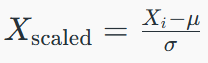

Brilliant example: https://www.geeksforgeeks.org/machine-learning/feature-engineering-scaling-normalization-and-standardization/

[1]: spectral_total: 27.02102072564242
[2]: rms: 21.3936529408819
[3]: skew: 20.659606167466364
[4]: std: 20.524541721465642
[5]: kurtosis: 12.949584403685927
[6]: spectral_bandwidth: 12.391030107690792
[7]: spectral_entropy: 11.14380282199496
[8]: ptp: 9.506794513676558
[9]: crest: 7.608919365460197
[10]: spectral_centroid: 7.024388367809419

Mean=2.2339252690520702e-14, Std=1.0


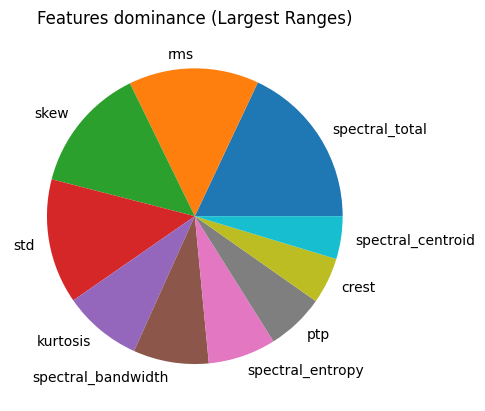

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_scaled = scaler.fit_transform(df[features].values)

df_scaled = pd.DataFrame(features_scaled, columns=features, index=df.index)
features_pie(df_scaled)

## My test
Take average of last 10 datapoints and if std if larger than average of rest of the datapoints then begin training model 

In [29]:
print(f"total: {len(df_scaled)}")
datapoints_up_to = len(df_scaled)-50

sliced_df = df_scaled.iloc[:datapoints_up_to]
print(f"taking: {len(sliced_df)}")



last_ten = sliced_df.iloc[len(sliced_df)-100:]

rest = sliced_df.iloc[:len(sliced_df)]
rest_avgs = []
last_ten_avgs = []
differences = []
for feature in features:
    rest_avg = np.mean(rest[feature])
    last_ten_avg = np.mean(last_ten[feature])
    
    difference = last_ten_avg - rest_avg
    differences.append((feature, difference))

    rest_avgs.append(rest_avg)
    last_ten_avgs.append(last_ten_avg)

print(differences)

if False:
    print(rest_avgs)
    print(last_ten_avgs)


total: 2156
taking: 2106
[('rms', 0.9418419905301517), ('std', 1.087218041134543), ('ptp', 2.3375098804275094), ('kurtosis', 2.0544710337782988), ('skew', -0.43731665092122873), ('crest', 2.3545580149936094), ('spectral_centroid', -1.422113716513033), ('spectral_bandwidth', -2.2174477242828337), ('spectral_total', 0.5329799142235015), ('spectral_entropy', -0.9586524053028824)]


## Window Differencing
Locking in healthy data for training - When the distance is conseqtively beyond threshold then lock in healthy data

In [30]:
import numpy as np

df_sliced = df_scaled
print(df_sliced.shape)


def euclidean_distance_recent_baseline(recent, all_previous):
    mu_recent = np.mean(recent, axis=0)
    mu_baseline = np.mean(all_previous, axis=0)
    return np.linalg.norm(mu_recent - mu_baseline)



WINDOW = 10
K_STABLE = 100    # How many consecative healthy bursts we need to declare the previous datapoints as heathy stable
THRESHOLD = 2.8   # Distance Threshold - Needs to be tuned for datasets

stable_counter = 0
lock_index = None

index = 0
# Sliding Window
for t in range(WINDOW, len(df_sliced)):

    recent = df_sliced[t-WINDOW:t]
    all_previous = df_sliced[:t-WINDOW]

    # if index >= 100:
    #     print(f"all_previous: {all_previous.shape}")
    #     print(f"recent: {recent.shape}")
    #     break

    if len(all_previous) < WINDOW:
        index+=1
        continue

    distance = euclidean_distance_recent_baseline(recent, all_previous)
    print(distance)

    if distance < THRESHOLD:
        stable_counter += 1
    else:
        stable_counter = 0

    if stable_counter >= K_STABLE:
        lock_index = t
        print(f"Healthy all_previous locked at index {lock_index}")
    
    index+=1

training_data = df_scaled[:lock_index]
training_data
    

(2156, 10)
0.2429368636824039
0.20154451956784958
0.2605694078455959
0.27245732292386127
0.30765338893784344
0.4214393966820621
0.43585596088148393
0.40897360325262677
0.5027109650132423
0.514843993168997
0.5086290767599891
0.3983762311847666
0.36770779984736
0.371763589022079
0.3125698955473687
0.2501721247508501
0.2494000366282063
0.20920486221393794
0.20966657249645124
0.17495397859971745
0.258927964845825
0.27227242885056524
0.20166401643853368
0.2883700858803393
0.23664198338519504
0.2193780690870861
0.3433074941514762
0.3209163908374638
0.3129322476712893
0.3076027495073097
0.250319539547627
0.2477174423157464
0.19111880144055254
0.25350830475962094
0.27288831506702105
0.2082296521966853
0.27566986746810107
0.21920455546333012
0.13229103777306642
0.161912929111998
0.10432656832637024
0.10999321066069799
0.1266173121441682
0.15108351004125792
0.1448175094713538
0.1918866541891817
0.1904095567908397
0.24003525295170652
0.2739856889610744
0.2843252791232173
0.2243818178080814
0.2072

,rms,std,ptp,kurtosis,skew,crest,spectral_centroid,spectral_bandwidth,spectral_total,spectral_entropy
2003-10-22 12:06:24,-1.517142,-1.006162,-0.741126,-0.285287,0.265050,-0.666860,2.227271,1.175711,-0.455892,-1.459177
2003-10-22 12:09:13,-1.486066,-0.994771,-0.572654,-0.277977,0.082990,-0.491227,2.130776,0.973014,-0.451779,-1.621079
2003-10-22 12:14:13,-1.404271,-0.991382,-0.647071,-0.288141,0.367368,-0.421212,2.607660,1.276615,-0.450566,-1.159302
2003-10-22 12:19:13,-1.416060,-0.967358,-0.763865,-0.311325,-0.052433,-0.544394,2.478084,1.266384,-0.441844,-1.413788
2003-10-22 12:24:13,-1.405721,-0.986395,-0.635702,-0.299669,0.225157,-0.611103,2.484288,1.217155,-0.448767,-1.151054
...,...,...,...,...,...,...,...,...,...,...
2003-11-22 14:56:56,0.258347,0.206446,0.512597,0.068835,-1.014744,1.203225,-1.080978,-0.534302,0.048846,-0.563958
2003-11-22 15:06:56,0.107481,0.117175,0.878481,0.241078,-1.067969,1.969756,-1.357270,-0.630334,0.007022,-0.067810
2003-11-22 15:16:56,0.255808,0.267764,1.146176,0.328957,-0.835038,1.756861,-1.419310,-1.258121,0.078001,-0.659525
2003-11-22 15:26:56,0.156952,0.105278,0.606652,0.112540,0.967259,0.767413,-1.434108,-0.353950,0.001469,0.139974


(1828, 10)
(328, 10)


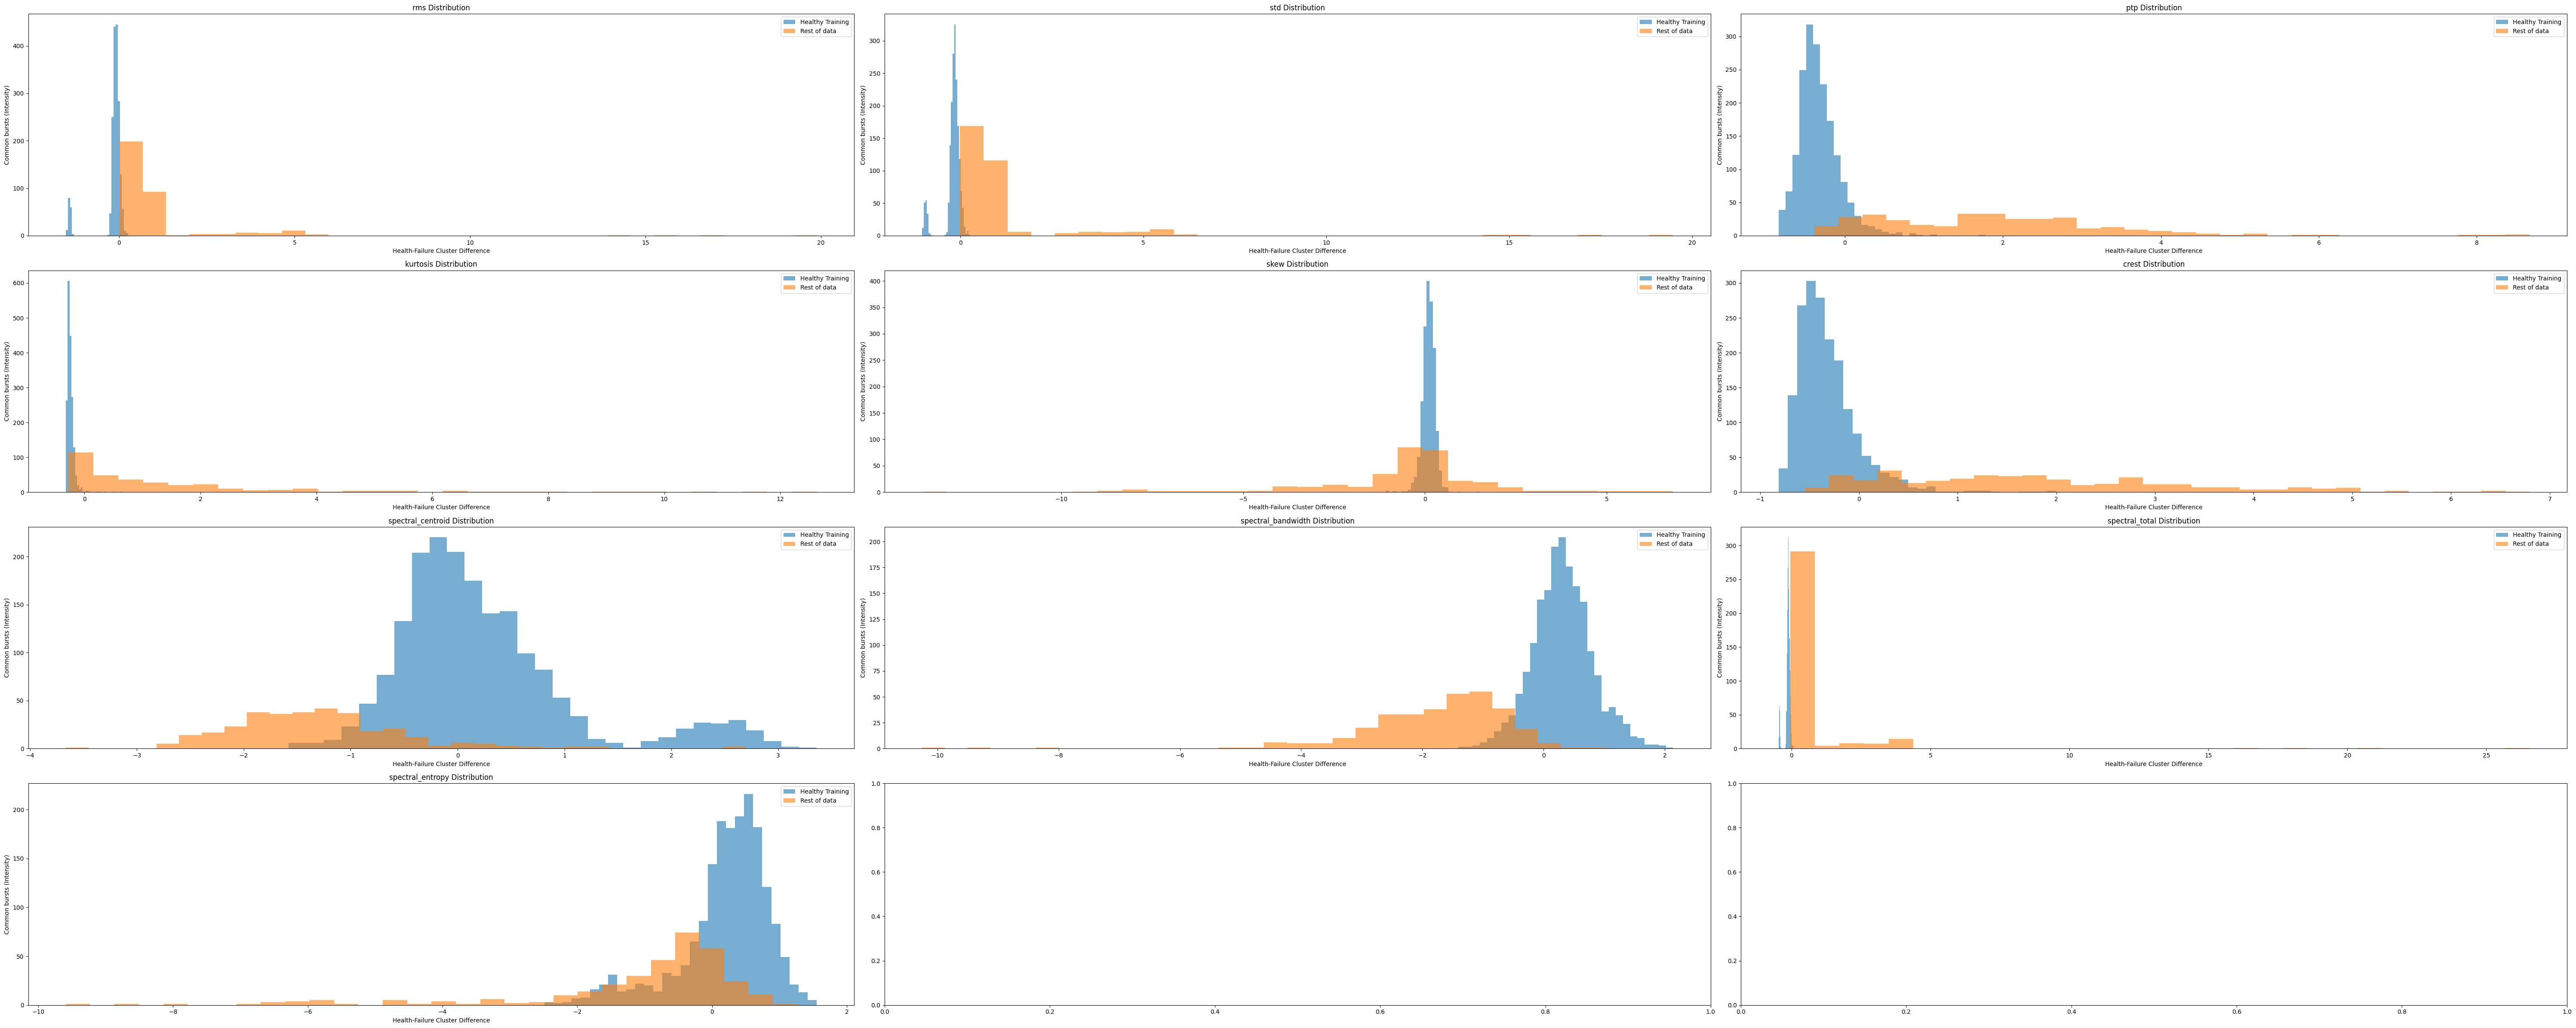

In [32]:
import math 

training_data = training_data
rest_of_data = df_scaled[lock_index:]
print(training_data.shape)
print(rest_of_data.shape)


# PLot
SHOW_ALL = True
features_to_plot:list

if SHOW_ALL:
    features_to_plot = features
    PLOTS_PER_ROW = 3
    fig, axes = plt.subplots(math.ceil(len(features)/PLOTS_PER_ROW), PLOTS_PER_ROW, figsize=(60,24))
else:
    # For image in diss
    features_to_plot = np.array(["kurtosis", "skew"])
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))


for col, f in enumerate(features_to_plot):
    row_index = math.floor(col / PLOTS_PER_ROW) # chop decimals off (round down) - every 3 plots increase row by 1
    col_index = col % 3 # when 3,6,9... come back to 0 

    if len(features_to_plot) > PLOTS_PER_ROW:
        # Resolving indexing error
        axe = axes[row_index, col_index]
    else:
        axe = axes[col]

    axe.hist(training_data[f], bins=30, alpha=0.6)
    axe.hist(rest_of_data[f], bins=30, alpha=0.6)
    axe.set_xlabel("Health-Failure Cluster Difference")
    axe.set_ylabel("Common bursts (Intensity)") # Values that are similar in a cluster accumalate a higher intensity in histogram
    axe.legend(["Healthy Training", "Rest of data"])
    axe.set_title(f"{f} Distribution")

plt.tight_layout()
plt.show()

#df.groupby('cluster_labels').mean()[features]

## Windowed Clustering 
Identify where datapoint deviations begin to happen
if deviation is large enough, take n prev datapoints and use as healthy training data

In [ ]:
from sklearn.cluster import KMeans

WINDOW_SIZE = 500
datapoints_captured = len(df_scaled)
print(f"Total datapoints: {datapoints_captured}")
window_blocks = int(datapoints_captured/WINDOW_SIZE)
print(f"Blocks: {window_blocks}")
for i in range(window_blocks):
    start_idx = i * int(WINDOW_SIZE/2)
    temp_block = df_scaled[start_idx:start_idx+WINDOW_SIZE]

    # Binary Classification
    kmeans = KMeans(n_clusters=2, random_state=42).fit(temp_block) # Do not include RUL nor time-indexing (just the feature columns)

    temp_block["cluster_labels"] = kmeans.labels_
    
    #df["cluster_labels"] = kmeans.labels_

    # Aggregate by label (0, 1)
    cluster_means = temp_block.groupby("cluster_labels").std()
    print(cluster_means[["rms", "kurtosis", "spectral_entropy"]])
    



Total datapoints: 2156
Blocks: 4
                     rms  kurtosis  spectral_entropy
cluster_labels                                      
0               0.046674  0.020546          0.385312
1               0.034886  0.015942          0.382684
                     rms  kurtosis  spectral_entropy
cluster_labels                                      
0               0.048185  0.029535          0.300315
1               0.045885  0.022711          0.339476
                     rms  kurtosis  spectral_entropy
cluster_labels                                      
0               0.079378  0.044361          0.320997
1               0.050583  0.023649          0.325221
                     rms  kurtosis  spectral_entropy
cluster_labels                                      
0               0.060486  0.025090          0.344289
1               0.066654  0.046832          0.338321


d:\Patrick\Uni\IP\Independent-Project-Contents\PdM\main\v\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_45592\2315858134.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_block["cluster_labels"] = kmeans.labels_
d:\Patrick\Uni\IP\Independent-Project-Contents\PdM\main\v\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(

## KMeans Clustering
Clustering used to identify healthy vs abnormal datapoints (so no labels needed - making this approach an unsupervised learning!)

Binary Classification (strictly 2 labels can be devised)

label 0 = Health
- RMS = low vib energy
- Kurtosis around 3-4 (close to gaussian noise)
- High-Freq ratio low = no impulsive fault energy

label 1 = Unhealthy
- RMS = vib energy increaing
- kurtosis > 3.7 (using NASA bearing ds) = impulsive events
- High-Freq ratio higher = fault related frequencies


The issue is, basic klustering only really works on RTF datasets. When livestreaming data only just starts showing signs of degradation, the basic klustering doesn't really pick up on it


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt



# Two groups (healthy, unhealthy)
kmeans = KMeans(n_clusters=2, random_state=42).fit(features_scaled) # Do not include RUL nor time-indexing (just the feature columns)

df_scaled["cluster_labels"] = kmeans.labels_
df["cluster_labels"] = kmeans.labels_

# Aggregate by label (0, 1)
cluster_means = df_scaled.groupby("cluster_labels").mean()
print(cluster_means[["rms", "kurtosis", "spectral_entropy"]])


# plt.scatter(cluster_means, cluster_means)
# plt.show()

d:\Patrick\Uni\IP\Independent-Project-Contents\PdM\main\v\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


ValueError: Length of values (1900) does not match length of index (2156)

Lower RMS, Kurtosis, Spectral total & Spectral centroid agree that **label 0 is healthy** & **label 1 is degrading**

Looking at High-Frequency Feature: 

cluster 0 len: 156
cluster 1 len: 1644
Cluster 0 min-max: 0.974-0.976 (Spread is 0.002)
Cluster 1 min-max: 0.975-0.978 (Spread is 0.003)


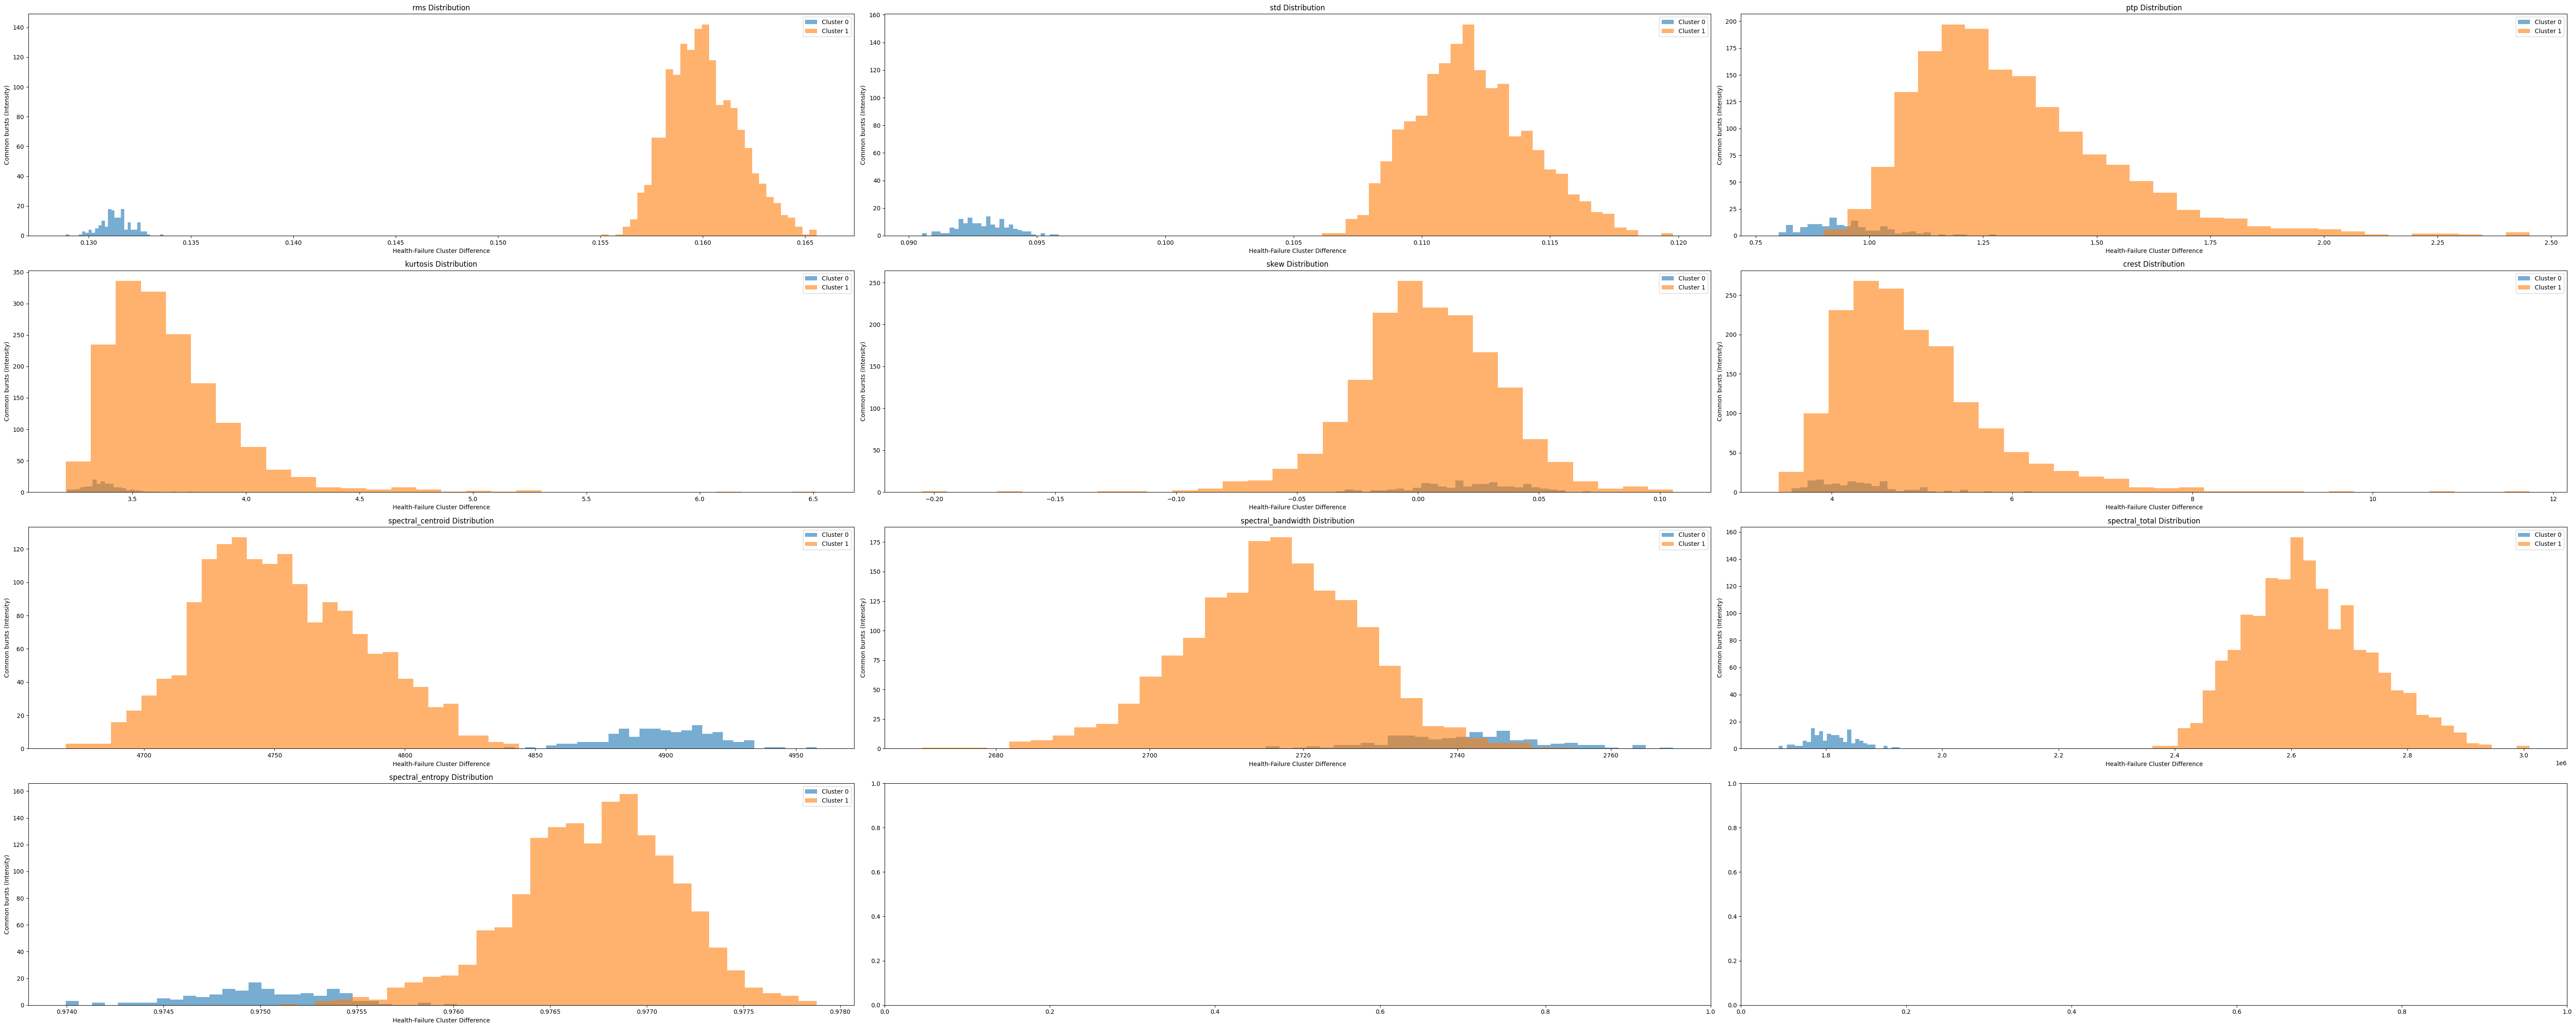

,rms,std,ptp,kurtosis,skew,crest,spectral_centroid,spectral_bandwidth,spectral_total,spectral_entropy
cluster_labels,,,,,,,,,,
0,0.131325,0.092930,0.950705,3.375084,0.021029,4.264908,4898.821238,2740.990636,1.811342e+06,0.974999
1,0.160073,0.111958,1.314619,3.658098,0.003395,4.892565,4752.828877,2716.165268,2.629800e+06,0.976727


In [ ]:
import matplotlib.pyplot as plt
import math

cluster0 = df[df["cluster_labels"] == 0]
cluster1 = df[df["cluster_labels"] == 1]
print("Looking at High-Frequency Feature: \n")
print(f"cluster 0 len: {len(cluster0)}")
print(f"cluster 1 len: {len(cluster1)}")
c0_min = round(cluster0["spectral_entropy"].min(), 3); c0_max = round(cluster0["spectral_entropy"].max(), 3)
c1_min = round(cluster1["spectral_entropy"].min(), 3); c1_max = round(cluster1["spectral_entropy"].max(), 3)
print(f"Cluster 0 min-max: {c0_min}-{c0_max} (Spread is {round(c0_max - c0_min, 3)})")
print(f"Cluster 1 min-max: {c1_min}-{c1_max} (Spread is {round(c1_max - c1_min, 3)})")

# PLot
SHOW_ALL = True
features_to_plot:list

if SHOW_ALL:
    features_to_plot = features
    PLOTS_PER_ROW = 3
    fig, axes = plt.subplots(math.ceil(len(features)/PLOTS_PER_ROW), PLOTS_PER_ROW, figsize=(60,24))
else:
    # For image in diss
    features_to_plot = np.array(["kurtosis", "skew"])
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))


for col, f in enumerate(features_to_plot):
    row_index = math.floor(col / PLOTS_PER_ROW) # chop decimals off (round down) - every 3 plots increase row by 1
    col_index = col % 3 # when 3,6,9... come back to 0 

    if len(features_to_plot) > PLOTS_PER_ROW:
        # Resolving indexing error
        axe = axes[row_index, col_index]
    else:
        axe = axes[col]

    axe.hist(cluster0[f], bins=30, alpha=0.6)
    axe.hist(cluster1[f], bins=30, alpha=0.6)
    axe.set_xlabel("Health-Failure Cluster Difference")
    axe.set_ylabel("Common bursts (Intensity)") # Values that are similar in a cluster accumalate a higher intensity in histogram
    axe.legend(["Cluster 0", "Cluster 1"])
    axe.set_title(f"{f} Distribution")

plt.tight_layout()
plt.show()

df.groupby('cluster_labels').mean()[features]

From above, can see Cluster 1 (anomalous values) are more spread on x axis, wheres in Cluster 0 (healthy values), they're tightly around the same healthy margin. 

Now we've got the seperation, we can use the healthy data (label 0) for the autoencoder!

## Select that healthy data for training material
Make sure to use the scaled features! not raw

In [ ]:
CLUSTERING = False
if CLUSTERING:
    healthy_df = df_scaled.loc[df_scaled["cluster_labels"]==0][features]
else:
    # New distance factoring
    healthy_df = training_data[features]
healthy_data = healthy_df.values

print("Shape format here (bursts count/rows, features count/cols)")
print(f"Health labelled data: {healthy_data.shape} - (All data: {df_scaled.shape})")

print(healthy_data)

# Sequence length is the amount of consecutive bursts to join together for assessing (rather than just 1 individual burst)
SEQUENCE_LENGTH = 20
healthy_sequences = []
for i in range(len(healthy_data) - SEQUENCE_LENGTH + 1):
    seq = healthy_data[i:i+SEQUENCE_LENGTH]
    #print(f"{i}: {seq}")
    healthy_sequences.append(seq)
healthy_sequences = np.array(healthy_sequences)

print("(Samples, Samples/Time steps, features per sample)")
print(f"Sequences: {healthy_sequences.shape}")


Shape format here (bursts count/rows, features count/cols)
Health labelled data: (157, 10) - (All data: (2156, 10))
[[-1.51714197 -1.00616166 -0.7411262  ...  1.17571149 -0.45589197
  -1.45917723]
 [-1.48606645 -0.99477104 -0.57265397 ...  0.97301375 -0.45177924
  -1.62107888]
 [-1.40427138 -0.99138156 -0.64707115 ...  1.2766148  -0.45056595
  -1.15930214]
 ...
 [-1.39112671 -0.93362393 -0.75352906 ...  0.52679525 -0.42956517
  -1.46243646]
 [-1.42147002 -0.96977099 -0.57368755 ...  1.38465537 -0.44274773
  -0.38181855]
 [-0.09736017 -0.11259652 -0.66464187 ...  0.37743996 -0.09729364
   0.37762441]]
(Samples, Samples/Time steps, features per sample)
Sequences: (138, 20, 10)


## LSTM Auto Encoder!

Revise components in Sequential Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense

features_count = len(features)

autoencoder = Sequential([
    # Input Layer - Using ReLU as paper, if large reconstruction error or dead neurons detected tne use tanh
    LSTM(64, activation="ReLU", input_shape=(SEQUENCE_LENGTH, features_count), return_sequences=False),
    RepeatVector(SEQUENCE_LENGTH), 
    # Output Layer
    LSTM(64, activation="ReLU", return_sequences=True),
    TimeDistributed(Dense(features_count))
])

autoencoder.compile(optimizer="adam", loss="mse")

autoencoder.summary()


Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_16 (LSTM)              (None, 64)                19200     
                                                                 
 repeat_vector_8 (RepeatVec  (None, 20, 64)            0         
 tor)                                                            
                                                                 
 lstm_17 (LSTM)              (None, 20, 64)            33024     
                                                                 
 time_distributed_8 (TimeDi  (None, 20, 10)            650       
 stributed)                                                      
                                                                 
Total params: 52874 (206.54 KB)
Trainable params: 52874 (206.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
# Check data is scaled (MSE was enormous as was using unscaled data by accident)
print(healthy_data.shape)

print(healthy_sequences.shape)

print(f"Min: {healthy_data.min()}")
print(f"Max: {healthy_data.max()}")
print(f"Mean: {healthy_data.mean()}")
print(f"Std: {healthy_data.std()}")


(157, 10)
(138, 20, 10)
Min: -2.487451340893424
Max: 3.3592804562048344
Mean: -0.19623002996975092
Std: 1.1445133906241365


Now train the model with the healthy data

In [25]:
# Healthy Sequences is the healthy training data remember

# Pass the Sequences in as input into our model.
history = autoencoder.fit(
    healthy_sequences,
    healthy_sequences,
    epochs=50,
    batch_size=32,
    validation_split=.1, # Ratio 
    shuffle=False
    )

print(f"Loss: {np.mean(history.history['loss'])}")
print(f"Val Loss: {np.mean(history.history['val_loss'])}")


NameError: name 'autoencoder' is not defined

All data (both healthy & unhealthy)

In [ ]:
all_data = df_scaled[features].values
print(all_data.shape)


all_sequences = []
for i in range(len(all_data) - SEQUENCE_LENGTH + 1):
    all_sequences.append(all_data[i:i+SEQUENCE_LENGTH])
all_sequences = np.array(all_sequences)

all_sequences.shape

(2156, 10)


(2137, 20, 10)

Anomaly Scores (health indicators)

<br>
Image shows autoencoder & decoder - taking the healthy data as input, outputting or "reconstructing" the data as an expected healthy state - the reconstruction error is how close it is to the original data fed in. so the anomalies will have a much larger error/distance from original data on reconstruction as it is unexpected values! This triggers anomaly detector then, and the most initial anomaly (first anomalous datapoint to go over threshold) is the onset degradation - this is where RUL countdown begins... Tick Tock...

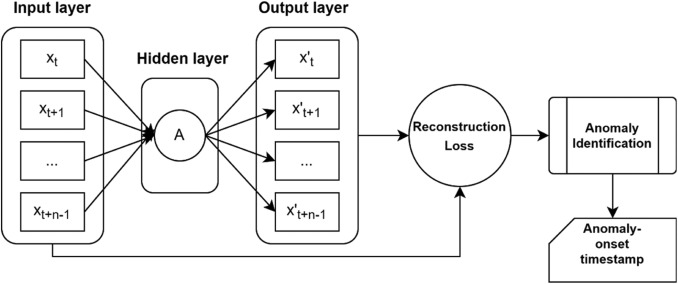

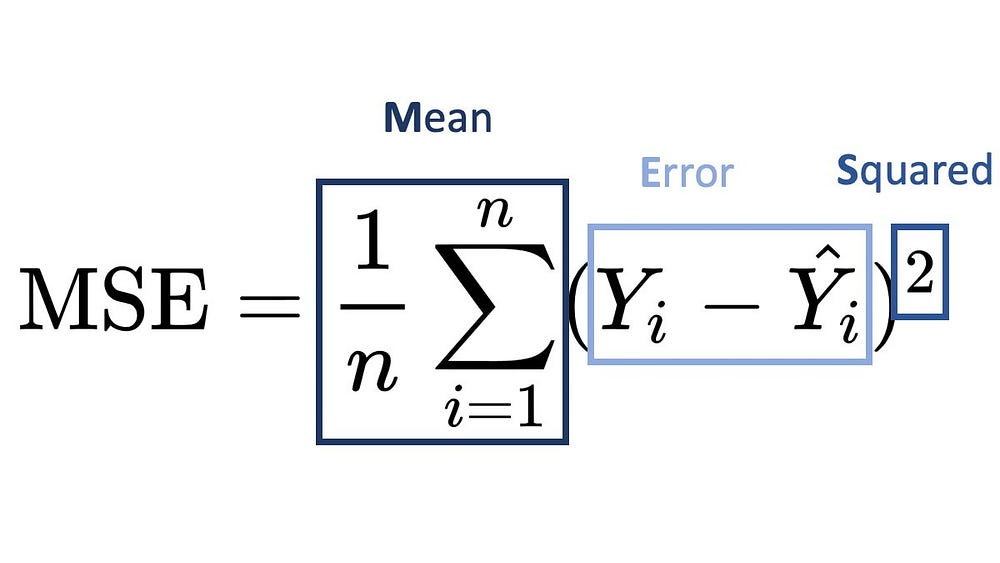

In [ ]:
# Predict what the continuing data should look like as healthy
reconstruction = autoencoder.predict(all_sequences)

# MSE Formula - https://en.wikipedia.org/wiki/Mean_squared_error
# Mean Squared Error (MSE) - Metric is indicative of the distance from the truth for a datapoint. The larger the error, the more anomalous that datapoint is to the previous healthy data 


# There are 2137 sequences, each sequence contains 20 bursts, each burst contains 11 features 
print(all_sequences.shape)
print(reconstruction.shape)


reconstruction_error = np.mean((all_sequences - reconstruction)**2, axis=(1,2)) 
reconstruction_error
print(len(reconstruction), len(all_sequences), len(reconstruction_error))


# Errors aligned with original timeline (bursts times) NOTE - First burst doesnt have an error (error is corresponds to last burst of each sequence)
error_series = pd.Series(
    reconstruction_error,
    index=df.index[SEQUENCE_LENGTH - 1:]
)
error_series


67/67 [==============================] - 0s 4ms/step
(2137, 20, 10)
(2137, 20, 10)
2137 2137 2137


2003-10-22 13:39:13     0.033946
2003-10-22 13:44:13     0.038387
2003-10-22 13:49:13     0.039929
2003-10-22 13:54:13     0.040099
2003-10-22 13:59:13     0.041495
                         ...    
2003-11-25 16:07:32    11.746854
2003-11-25 23:13:21    17.702155
2003-11-25 23:19:56    24.314497
2003-11-25 23:29:56    29.068231
2003-11-25 23:39:56    37.294707
Length: 2137, dtype: float64

### We now effectively have health scores 

Spikes are indicative of unexpected values, not seen during training (in healthy state). These pick up near the end of the time-series data as expected, beacuse this is where the bearing is wearing out.

The reconstruction loss (distance from predicted "expected healthy" datapoints to the actual datapoint value) are indicative of the machines health. the larger the reconstruction loss/error, the worser the health as it is further from the expected healthy range.

"anomaly scores", "health indicator", "reconstruction error", "reconstruction loss" are interchangable terminology for this:

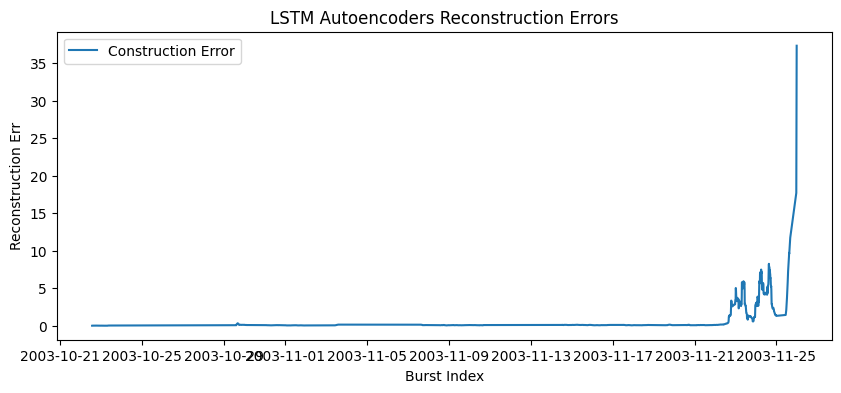

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(error_series, label="Construction Error")
plt.title("LSTM Autoencoders Reconstruction Errors")
plt.xlabel("Burst Index")
plt.ylabel("Reconstruction Err")

plt.legend()
plt.show()

### Finding Anomaly onset timestamp 
So after the onset (first genuine anomaly spike), the machine is entering its degradation period

Uses 68-95-99 Rule:
Setting p to the percentage so in Pr function:
- p = 1 = 68%
- p = 2 = 95% 
- p = 3 = 99.7%

Source: https://en.wikipedia.org/wiki/68%E2%80%9395%E2%80%9399.7_rule

<br>

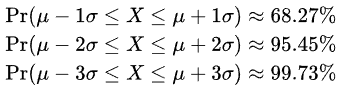

Where:

- X = Each reconstruction error
- σ = Sigma (Std) across the healthy errors (errors during healthy period)
- μ = Mu (Mean) across the healthy errors


In [ ]:
healthy_error = error_series.loc[healthy_df.index[SEQUENCE_LENGTH-1:]]
# Smoothing ensures that anomaly occurances persist over more than one burst (window=5)
# Thus, good for reducing false positives
smoothed_error = error_series.rolling(window=5, min_periods=1).mean()


mu = healthy_error.mean() # mu μ is terminology in math for mean
sigma = healthy_error.std() # Sigma σ is terminology in math for std 


# Anomalies are those with errors above threshold
# Using 68-95-99.7 rule! - (Also if using p=3, this is known as Three-Sigma Rule)
# p=  1(68%), 2(95%) or 3(99.7%)
P = 1
# Same as probability function (Pr())
anomalies = error_series.loc[~((mu - (P*sigma) <= error_series) & (error_series <= mu + (P*sigma)))]
print(f"Abnormal Values found: {len(anomalies)} ({len(error_series)} values in total)")

# Therefore, the upper limit (positive threshold that determines anomalies) is: mu + (p*sigma)
# Formula is "Upper Control Limit" - Three-Sigma Rule (https://www.geeksforgeeks.org/maths/68-95-99-rule/)
threshold = mu + (P * sigma)
print(f"Threshold: {threshold}")

# Beginning of anomalous/unexpected behaviour
first_abnormal_idx = error_series[error_series > threshold].index[0]
print(f"Intitial anomaly onset: {first_abnormal_idx}")

plt.figure(figsize=(10,4))
plt.plot(smoothed_error, label="err (smoothed)")
plt.plot(error_series.index, [threshold for _ in range(len(error_series))], label="threshold", linestyle="--")
plt.plot([first_abnormal_idx,first_abnormal_idx],[0,smoothed_error.max()], label="First Anomaly", linestyle="--")
plt.plot(anomalies, label="Anomalies")
plt.title("LSTM Autoencoders Reconstruction Errors")
plt.xlabel("Burst Index/timestamps")
plt.ylabel("Reconstruction Err")
plt.legend()
plt.show()

NameError: name 'error_series' is not defined

### Important Note before looking at below Estimating RUL
THIS APPROACH IS KNOWING THE FAILURE (tf)
This approach below is using the NASA bearing dataset which is run-to-failure.Therefore, we can use the below forumla as we know when/what tf is (the end of the degradation period is the failure "tf"). 

Using this approach on an unknown machine would require that:
- The machine(s) this entire notebook is calibrated & predicting for are similar in configuration/placement of sensors & structure of machine. (obvious)
- The machine(s) are ran to failure a few times & tracked, to gather degradation period for the RUL regression prediction below

<br>
<hr>

Alternative to the regression based RUL is Health-based RUL.
Where instead of predicting time till failure, we predict the distance to failure in latent health space. 
So, 
- How fast anomaly scores (reconstruction errors) are growing


<br>
<br>
<br>

### Estimating RUL (Regression Based) 
Training data required is the degredation period (near end of life) 

Clip dataset at anomaly onset time to failure (end)

<br>

![RUL Forumla from clipped dataset](media/Regressive_RUL.png)

- ta = First genuine anomaly (anomaly onset time)
- tf = Last datapoints in clipped degradation (failure time)
- t = current datapoint in clipped dataset

In [ ]:
# Col is Construction Error (loss)
# for t >= ta
degradation_period = smoothed_error[first_abnormal_idx:]
degradation_period_df = pd.DataFrame(degradation_period, columns=["R_Error"])
# Data is now clipped, from the onset of degradation onwards to end as shown in the paper
degradation_period_df

# Last datapoint (tf)
failure_timestamp = degradation_period_df.index[-1]
failure_timestamp

degradation_period_df["RUL_seconds"] = (failure_timestamp - degradation_period_df.index).total_seconds()
degradation_period_df


,R_Error,RUL_seconds
2003-10-22 13:39:13,140483.504560,2805731.0
2003-10-22 13:44:13,140172.976545,2805431.0
2003-10-22 13:49:13,138911.594303,2805131.0
2003-10-22 13:54:13,138963.465190,2804831.0
2003-10-22 13:59:13,139111.659398,2804531.0
...,...,...
2003-11-24 00:21:24,4.256695,2400.0
2003-11-24 00:31:24,4.476486,1800.0
2003-11-24 00:41:24,4.700053,1200.0
2003-11-24 00:51:24,5.004653,600.0


<Axes: >

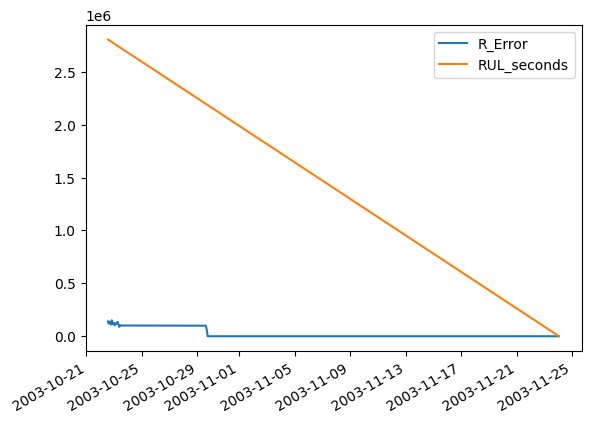

In [ ]:
degradation_period_df.plot()

### Estimating RUL (Live Conditinal-Health-Based)
so instead of looking at current t-t_failure, score RUL depending on the speed of increase on the anomaly score (reconstruction errors)

This doesn't give an absolute/exact time of failure - as this is impossible. Although this gives a pretty good indicator that actions are required & the impending failures arising. This is monitors current conditions and the growing change in abnormal sensor readings 

![Health Based RUL forumla from onset onwards](media/HealthBased_RUL.png)

![](media/HealthBased_RUL2.png)


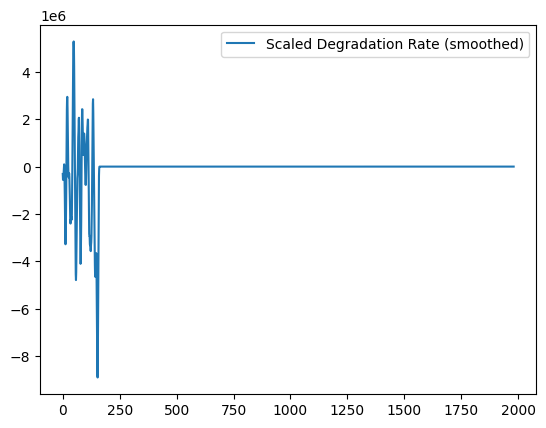

In [ ]:
critical_health_threshold = threshold
# Beyond this point, the machine is becoming uncomfortable to continue operating (requires attention & maintanence)
critical_health_threshold

# Slope I believe 
estimated_degradation_rate = np.gradient(smoothed_error.values) # np.gradient(smoothed_error.values)
rate_smoothed = pd.Series(estimated_degradation_rate).rolling(5, min_periods=1).mean()

rate_smoothed

# ?
epsilon = 1e-6

RUL_health = (critical_health_threshold - smoothed_error) / np.maximum(estimated_degradation_rate, epsilon)

plt.plot(rate_smoothed*1000, label="Scaled Degradation Rate (smoothed)")
plt.legend()
plt.show()


Can see unsurity of RUL - As after the first bearing fault (first spike), the health-indicator goes back to its usual (healthy looking) range. When at this point the damage is accumalting, it is masked as the RUL comes back down indicating its healthy

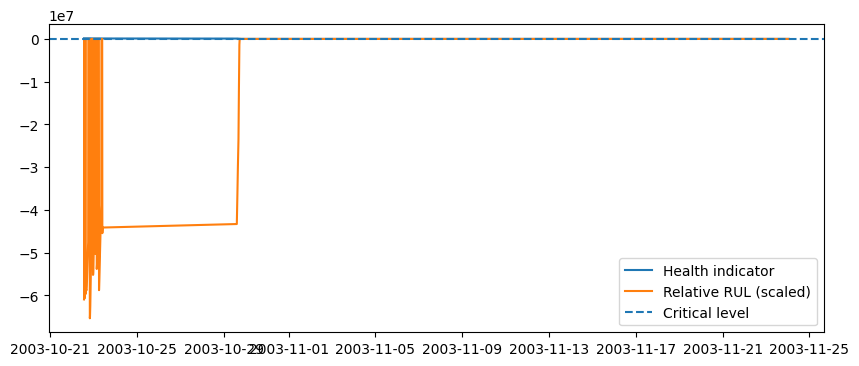

Series([], dtype: float64)


In [ ]:
import datetime
plt.figure(figsize=(10,4))
plt.plot(smoothed_error, label="Health indicator")
plt.plot((RUL_health / RUL_health.max())*1000, label="Relative RUL (scaled)")
plt.axhline(critical_health_threshold, linestyle='--', label="Critical level")
plt.legend()
plt.show()

print(RUL_health[datetime.datetime.strptime("2004/02/17 11:00:00", "%Y/%m/%d %H:%M:%S"):])

In [ ]:
# Uses Eulers constant 2.71828 (base of natural logarithm & exponential grown)
# does e ** [x,y,...]
e = 2.71828
print(np.exp([2]))
# Same as
exp = e ** 2
print(exp)


[7.3890561]
7.3890461584


## Live Health Index (Exponentially Weighted Moving Average)
weights decay over time - most recent values are most impactful

Mines Linear Damage Rule factors the accumalted damage from varying stress levels & predicting its fatigue

## Exponentially Weighted Moving Average
Moving average effectively treats most recent datapoints as the most infleunctial. previous datapoints fade out. 

Used here: https://wes.copernicus.org/articles/10/2841/2025/wes-10-2841-2025.html

In [ ]:
lam = .1
# degradation_period = 
Z = pd.Series(0.0, index=error_series.index)

first_abnormal_idx_position = error_series[first_abnormal_idx]


for t in range(len(Z)):
    RE_t = error_series.iloc[t]
    Z_prev = Z.iloc[t-1]
    Z_t = lam * RE_t + (1-lam) * (0 if t==0 else Z_prev)
    
    if t >= 2110:
        print(Z.quantile(.95))
        break
    #Z_t_scaled = Z_t / 
    Z.iloc[t] = 1 - Z_t



HI = pd.Series(Z, index=error_series.index)
HI = np.exp()
#HI = Z / (Z.quantile(.95) / (1 - lam) )

HI[first_abnormal_idx:].plot()

TypeError: exp() takes from 1 to 2 positional arguments but 0 were given

In [ ]:
# Damage
ALPHA = 0.95
e = np.maximum(smoothed_error - threshold, 0)


REVERSE_TIME = 0

# 2.1 Exponentially weighted moving averge - https://arxiv.org/pdf/2404.08136
β = .95  # must be an element of range (0-1) # forgetting factor, ranges from 1 (most recent and most impactful) to 0 (earliest & least impactful)
x = smoothed_error
T = len(x)
damage = pd.Series(0.0, index=x.index[:-1-(REVERSE_TIME-1 if REVERSE_TIME != 0 else 0)])
fatigue = []

print(len(damage))
# at each T
for t in range(1, T):
    # sum in equation goes over it again in 0(n) time
    a_t = ( sum([β**(t-τ) for τ in range(1, t+1)]) )**-1 # Using computational indexing (start at 0)


    # Shown in (1)
    x_t = a_t * ( sum([(β**(t-τ))*x[τ-1] for τ in range(1, t+1)]) )

    #print(x_t)
    
    print(t-1)
    damage.iloc[t]


    continue

    # weight = β**(t-) # the exponential decay β^t−τ

    values_age = t - T

    ALPHA * damage.iloc[i-1]
    print(damage.iloc[i-1])
    damage.iloc[i] = ALPHA * damage.iloc[i-1] + e.iloc[i]
    

print(damage)


2136
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
2

IndexError: single positional indexer is out-of-bounds

## Exponetially Weighted Moving Sum (EWMS)
Most papers use EWMAverage, although I reckon if we can scale the health index back to 1.0 (normalise afterwards), this can be used.

This effectively using the lambda (forgetting factor) to bring the accumulating 
value at _n back down when errors decline (so it doesnt cumsum). It's similar to cumsum
in that when errors keep arising the damage score picks up 

2102
2003-10-22 17:19:38    -0.000000
2003-10-22 17:24:13    -0.044470
2003-10-22 17:34:13    -0.054606
2003-10-22 17:44:13    -0.057284
2003-10-22 17:54:13    -0.058530
                         ...    
2003-11-25 15:57:32   -13.386485
2003-11-25 16:07:32   -13.768439
2003-11-25 23:13:21   -15.284167
2003-11-25 23:19:56   -18.289428
2003-11-25 23:29:56   -22.496532
Length: 2102, dtype: float64


<Axes: >

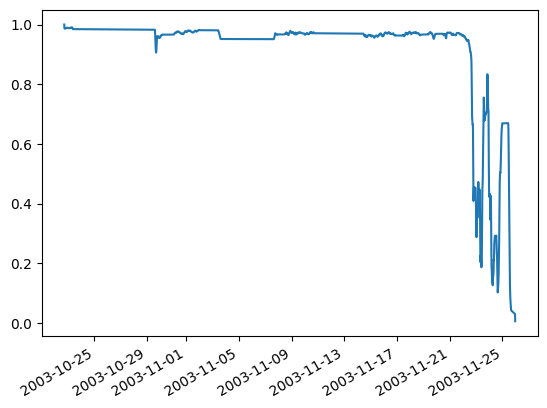

In [ ]:
d_signal = smoothed_error[first_abnormal_idx:] # np.maximum(smoothed_error - threshold, 0)


# This allows the damage score to come back down when error shrink
# If this is 1 then there is no forgetting factor (1) acts as a cumsum
_lambda = .2 

# Note, remember when you do REVERSE_TIME = anything but 0, it is leaving the rest to be set to
# 0.0 as above defines a series of 0.0s initially.
REVERSE_TIME = 0 # n datapoints to chop off end
damage = pd.Series(0.0, index=d_signal.index[:-1-(REVERSE_TIME-1 if REVERSE_TIME != 0 else 0)]) # Chopping n datapoints off the tail (end)

print(len(damage))

# (1) Damage is accumalative 
for n in range(1, len(damage)):
    N = d_signal.iloc[n]
    # Unscaled exponentially weighted sum
    # Same result as _lambda * damage! - Exponentially Weighted Moving Average? 
    # Forgetting factor brings value back down when errors shrink
    damage.iloc[n] = (damage.iloc[n-1] * _lambda) + d_signal.iloc[n]

#    damage.iloc[n] = (_lambda * damage.iloc[n-1]) + d_signal.iloc[n]

# Damage should come down as errors accumalate (invert inreasing damage to decreasing)
damage = -damage
print(damage)


# Scaling by the upper/larger values around the .95% mark
damage_scaled = damage / d_signal.quantile(.95)

# Exponential normalisation i think (ensures values stay within 1-0) 
HI = np.exp(damage_scaled)

HI.plot()

In [ ]:
d_signal = smoothed_error[first_abnormal_idx:] # np.maximum(smoothed_error - threshold, 0)
d_signal[d_signal < threshold] = 0


# This allows the damage score to come back down when error shrink
# If this is 1 then there is no forgetting factor (1) acts as a cumsum
_lambda = .9

# Note, remember when you do REVERSE_TIME = anything but 0, it is leaving the rest to be set to
# 0.0 as above defines a series of 0.0s initially.
REVERSE_TIME = 0 # n datapoints to chop off end
damage = pd.Series(0.0, index=d_signal.index[:-1-(REVERSE_TIME-1 if REVERSE_TIME != 0 else 0)]) # Chopping n datapoints off the tail (end)

print(len(damage))

# (1) Damage is accumalative 
for n in range(1, len(damage)):
    N = d_signal.iloc[n]
    # Unscaled exponentially weighted sum
    # Same result as _lambda * damage! - Exponentially Weighted Moving Average? 
    # Forgetting factor brings value back down when errors shrink
    damage.iloc[n] = (_lambda * damage.iloc[n-1]) + (1 - _lambda) * d_signal.iloc[n]

#    damage.iloc[n] = (_lambda * damage.iloc[n-1]) + d_signal.iloc[n]

# Damage should come down as errors accumalate (invert inreasing damage to decreasing)
damage = -damage
print(damage)


# Scaling by the upper/larger values around the .95% mark
damage_scaled = damage / d_signal.quantile(.95)

# Exponential normalisation i think (ensures values stay within 1-0) 
HI = np.exp(damage_scaled)

HI.plot()

NameError: name 'smoothed_error' is not defined

2137
2136
damage: 2003-10-22 13:39:13        0.000000
2003-10-22 13:44:13        0.064202
2003-10-22 13:49:13        0.127744
2003-10-22 13:54:13        0.190734
2003-10-22 13:59:13        0.253609
                           ...     
2003-11-25 15:57:32    26606.439444
2003-11-25 16:07:32    27931.845091
2003-11-25 23:13:21    28621.002376
2003-11-25 23:19:56    28437.897338
2003-11-25 23:29:56    27852.342701
Length: 2136, dtype: float64
eps: 2856.470471332715 - Dcrit: 57129.40942665425 
 Dcrit = 2856.470471332715 / (1-0.95) - 57129.40942665425 = 2856.470471332715 / 0.050000000000000044
2003-10-22 13:39:13    1.000000
2003-10-22 13:44:13    0.999999
2003-10-22 13:49:13    0.999998
2003-10-22 13:54:13    0.999997
2003-10-22 13:59:13    0.999996
                         ...   
2003-11-25 15:57:32    0.627682
2003-11-25 16:07:32    0.613287
2003-11-25 23:13:21    0.605933
2003-11-25 23:19:56    0.607878
2003-11-25 23:29:56    0.614141
Length: 2136, dtype: float64


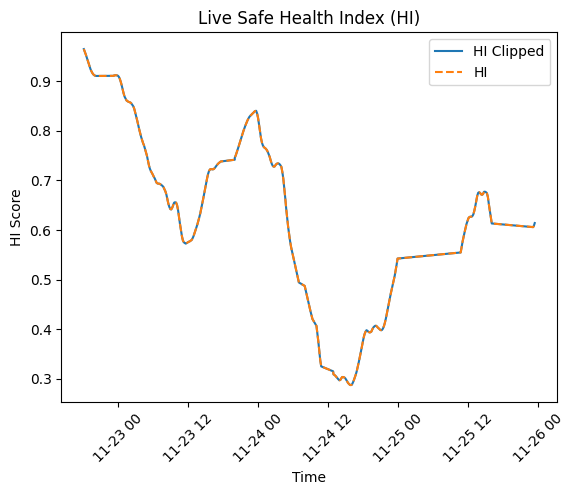

In [ ]:
# Damage
ALPHA = 0.95
e = smoothed_error # np.maximum(smoothed_error - threshold, 0)

print(len(e))

# Note, remember when you do REVERSE_TIME = anything but 0, it is leaving the rest to be set to
# 0.0 as above defines a series of 0.0s initially.
REVERSE_TIME = 0 # n datapoints to chop off end
damage = pd.Series(0.0, index=e.index[:-1-(REVERSE_TIME-1 if REVERSE_TIME != 0 else 0)]) # Chopping n datapoints off the tail (end)

print(len(damage))

# Damage is accumalative
for i in range(1, len(damage)):
    damage.iloc[i] = ALPHA * damage.iloc[i-1] + e.iloc[i]


print(f"damage: {damage}")

# Epsilion - Miners Rule
# Causal reference scale
eps = e.quantile(0.98)
Dcrit = eps / (1 - ALPHA)
print(f"eps: {eps} - Dcrit: {Dcrit} \n Dcrit = {eps} / (1-{ALPHA}) - {Dcrit} = {eps} / {1-ALPHA}")
# Health Index
# why exponential 
HI = np.exp(-damage / Dcrit)
print(HI)
HI_clipped = HI.clip(0, 1)

plt.plot(HI_clipped.loc[first_abnormal_idx:], label="HI Clipped")
plt.plot(HI.loc[first_abnormal_idx:], label="HI", linestyle="--")
plt.xticks(rotation=45)
plt.title("Live Safe Health Index (HI)")
plt.ylabel("HI Score")
plt.xlabel("Time")
plt.legend()
plt.show()


Health Index (HI)

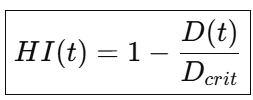

<br>

And clipped (at 1.0-0)

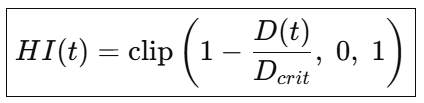

first anomaly:  2003-11-22 17:36:56
Min D: 0.0; Max D: 65248.88741326446; Dcrit: 64182.103300549345


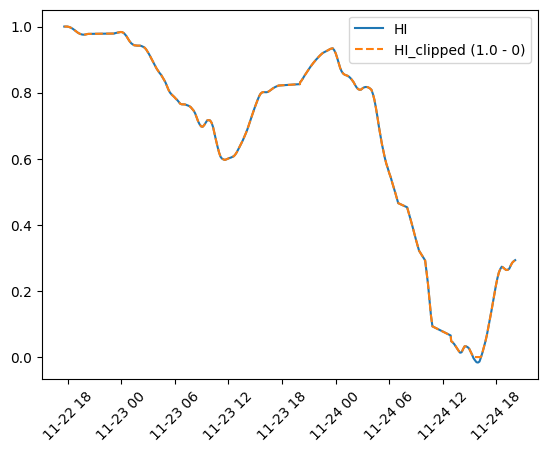

In [ ]:
# Temp block - Trial and error (testing block)

print("first anomaly: ", first_abnormal_idx)
# .95 = Conservative fatigue
# .97 = slow degradation
# .99 = safety critical assets ?? 
ALPHA = .95

e = np.maximum(smoothed_error - threshold, 0)
damage = pd.Series(index=e.index, dtype=float)
damage.iloc[0] = 0

# NOT LIVE - Removing below datapoints from end always results in a final Health Index of 0...
TEST_LIVE = 60
for i in range(1, len(e)-TEST_LIVE):
    damage.iloc[i] = (ALPHA * damage.iloc[i-1]) + e.iloc[i]


# Accumalated Damage
D = damage
Dcrit = D.loc[first_abnormal_idx:].quantile(.98) #threshold # Dcrit = D.quantile(.939)

print(f"Min D: {D.min()}; Max D: {D.max()}; Dcrit: {Dcrit}")

HI = 1 - (D / Dcrit)

HI_clipped = HI.clip(0, 1)

# plt.plot(D.loc[first_abnormal_idx:] / D.loc[first_abnormal_idx].min(), label="Damage Rate (Diff)", linestyle="--")
# plt.plot(error_series[first_abnormal_idx:], label="Reconstruction Err")
plt.plot(HI.loc[first_abnormal_idx:], label="HI")
plt.plot(HI_clipped.loc[first_abnormal_idx:], label="HI_clipped (1.0 - 0)", linestyle="--")

plt.legend()
plt.xticks(rotation=45)
plt.show()

<Axes: >

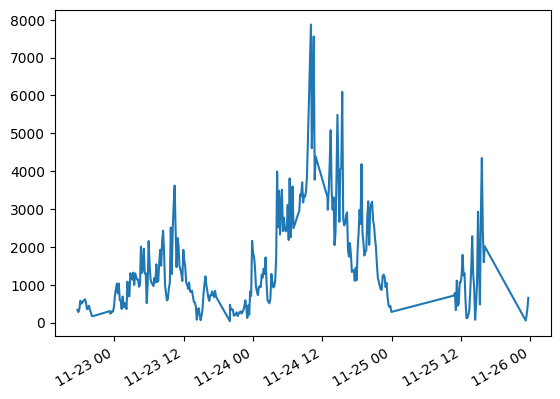

In [ ]:
error_series[first_abnormal_idx:].plot()

Changing to monotonic damage accumulation
- After the damage spike, dont decrease RUL back down to baseline

<hr>

<ins>Using Cummulative Summative:</ins> <br>
cumsum([1, 3, 5, 7])
1. 1
2. 4
3. 9
4. 16


<ins>Explanation:</ins>
1. 1
2. 1+3 = 4
3. 4+5 = 9
4. 9+7 = 16


Quantile is the value(s) in a distribution that is at the qth quantile (percent) 
<br>so, in [20, 10, 15, 5, 25] (min=5, max=25)
- quantile(.01) = 5.2 (around 5 as 1% margin in distrubution is near lowest which is 5)
- quantile(.25) = 10
- quantile(.50) = 15 (Half way point, also known as MEDIAN)
- quantile(.75) = 20 
- quantile(.99) = 24.8 (.1 or 100% will equal 25 and this is the largest in array)

first anomaly:  2003-11-22 17:36:56


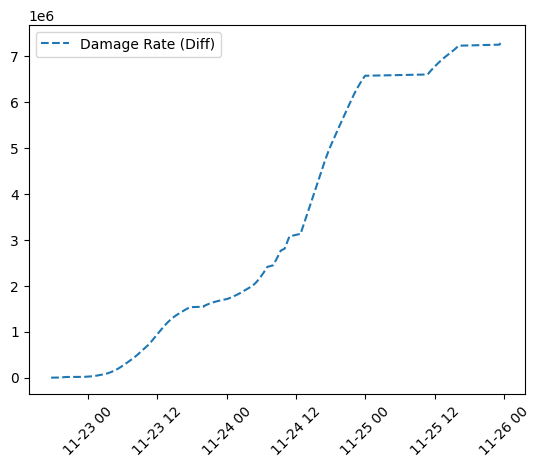

In [ ]:
# Temp block - Trial and error (testing block)

print("first anomaly: ", first_abnormal_idx)
# .95 = Conservative fatigue
# .97 = slow degradation
# .99 = safety critical assets ?? 
ALPHA = .95

e = np.maximum(smoothed_error - threshold, 0)
damage = pd.Series(index=e.index, dtype=float)
damage.iloc[0] = 0


for i in range(1, len(e)):
    damage.iloc[i] = (ALPHA * damage.iloc[i-1]) + e.iloc[i]


# Accumalated Damage
D = damage.cumsum()

plt.plot(D.loc[first_abnormal_idx:], label="Damage Rate (Diff)", linestyle="--")
# plt.plot(RUL / RUL.min(), label="Remaining Useful Life (RUL)")
# plt.plot(RUL2, label="RUL2")
# plt.plot(test, label="Damage Rate with Memory")
plt.legend()
plt.xticks(rotation=45)
plt.show()

if False:
    # NOTE, the damage increases dramatically over time. Current time writing this note
    # The RUL dimishes more near the end as these are much more impactful
    print("first over threshold value: ", damage.loc[damage>0].index[0], " with value ", damage.loc[damage>0][0] )
    print("\nDamages: ", damage.loc[damage>0])
    # print(damage)#.plot()

    # Same damage-rate cacluation (difference between neighbours identifies contiguous changes)
    WINDOW = 10
    damage_rate = damage.diff(WINDOW) / WINDOW
    impactful_damage_rate = damage_rate[damage_rate>0]
    lowest_rate_of_change = impactful_damage_rate.quantile(.1)
    highest_rate_of_change = impactful_damage_rate.quantile(.99)
    print("\nLowest rate of change in impactful (>0) data rate: ", lowest_rate_of_change)
    print("Highest rate of change in impactful (>0) data rate: ", highest_rate_of_change)

    # Clip Lower bounds - to make smaller damage rates have no impact (damage ranges < .1 quantile, will ?)
    lower_boundary = impactful_damage_rate.quantile(.1) 
    # Set (clip) values below the lowest_rate_of_change to this boundary (-2, -1, 2 < 1 -> clip -> 1, 1, 2)
    damage_rate = damage_rate.clip(lower=lower_boundary) # clip values to > .000001
    print("Damage Rage: ", damage_rate)



    # "In historical data, 99.5% of the time damage was below "
    critical_damage_score = damage.quantile(.95)
    print("Critical damage score: ", critical_damage_score)


    active_mask = damage > 0
    RUL = pd.Series(index=damage.index, dtype=float)
    print(RUL[1])

    STARTING_SCORE = 0
    damage_rate = damage_rate.loc[first_abnormal_idx:]
    damage_rate_w_memory = damage_rate.cummax()
    print("damage rate with mem: ", damage_rate_w_memory)


    damage_memory = (damage.cummax())
    RUL2 = damage + damage_rate_w_memory#.quantile(.95)

    IMPACT_ON_RUL = .2
    #RUL = (((STARTING_SCORE-damage) / (damage_rate*2)) - (damage - damage_rate_w_memory)) * IMPACT_ON_RUL

    RUL = -((((damage + damage_rate_w_memory)*IMPACT_ON_RUL)))
    RUL = -((((smoothed_error+damage_rate_w_memory) * (damage_rate*.002))))

    # RUL = -((((smoothed_error / damage_rate))+(damage_rate_w_memory)))
    #RUL = -((((smoothed_error / damage_rate)*IMPACT_ON_RUL)+(damage_rate_w_memory)))


    RUL = RUL[first_abnormal_idx:]
    # RUL.plot()

    # BOOL-Series, Get where confident degration is real
    # Sets true there damage is more than the upper-qauter quantile (top/highest 25% damage scores will be true)
    confidence = (damage > damage.quantile(.75)) #(damage > damage.quantile(.75))
    # RUL.plot()
    print("Confidence: ", confidence)

    print("Confidence is true: ", confidence.loc[confidence].index)
    # RUL.loc[1] = 100


    # RUL.loc[confidence] = np.maximum.accumulate(
    #     RUL.loc[confidence][::-1]
    # )[::-1]
    # RUL = RUL.abs()
    # RUL.plot()

    print("RUL Estimation begins: ", RUL.index[0])

    if False:
        beginning_of_RUL_diminish = RUL[RUL>1750].index[-1]
        print("\nBeginning of dimishinment of RUL ", beginning_of_RUL_diminish)
        print("damage rate at this time: ", damage_rate[beginning_of_RUL_diminish - datetime.timedelta(hours=0)])
        # I dunno


    print(RUL.index[0])

    #plt.subplot2grid((2,1))
    plt.plot(damage.loc[first_abnormal_idx:], label="damage")
    plt.plot(error_series.loc[first_abnormal_idx:], label="Reconstuction Errors (AE)", linestyle="--")
    plt.plot(damage_rate.loc[first_abnormal_idx:], label="Damage Rate (Diff)", linestyle="--")
    # plt.plot(RUL / RUL.min(), label="Remaining Useful Life (RUL)")
    # plt.plot(RUL2, label="RUL2")
    # plt.plot(test, label="Damage Rate with Memory")
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
damage = smoothed_error.copy()
# Set Non-Impactful rows (below threshold) to 0 - This brings ALL erros down by (-threshold)
# This is the same as doing:
# excess = smoothed_err - thres; (sub threshold from each error reading)
# excess_clipped = excess[excess < 0] = 0; (Set negative values to 0)
excess = np.maximum(smoothed_error - threshold, 0)
# print(excess.loc[excess > 0])




# print(threshold)
# damage[first_abnormal_idx:] = 0 # Below breaking threshold, not damaged, set to 0 to have no effect
damage = excess.cumsum() # Accumalative - retains previous errors
print(damage)
print(f"First anomaly: {damage[first_abnormal_idx]}")

WINDOW = 10
damage_rate = damage.diff(WINDOW) / WINDOW
damage_rate = damage_rate.clip(lower=1e-6) # clip values to > .000001


baseline = 5
critical_damage_threshold = baseline * damage[damage > 0].median() # Live 
critical_damage_threshold = 1.05 * damage.iloc[-1]
print(f"critical_damage_threshold ({critical_damage_threshold}) = 1.05 * {damage.iloc[-1]}")


# TODO
# Maybe try scaling damage down to make RUL less sensitive - already usnig cumsum to retain
# previous damage spikes
a = (critical_damage_threshold - damage)
print(a)
RUL_health_history = (a - damage) / damage_rate
# RUL_health = np.clip(RUL_health, 0, None)


2003-10-22 13:39:13         0.000000
2003-10-22 13:44:13         0.000000
2003-10-22 13:49:13         0.000000
2003-10-22 13:54:13         0.000000
2003-10-22 13:59:13         0.000000
                           ...      
2003-11-25 16:07:32    381914.600066
2003-11-25 23:13:21    383700.640397
2003-11-25 23:19:56    384648.876268
2003-11-25 23:29:56    385185.507288
2003-11-25 23:39:56    385533.757755
Length: 2137, dtype: float64
First anomaly: 0.0
critical_damage_threshold (404810.44564304553) = 1.05 * 385533.75775528146
2003-10-22 13:39:13    404810.445643
2003-10-22 13:44:13    404810.445643
2003-10-22 13:49:13    404810.445643
2003-10-22 13:54:13    404810.445643
2003-10-22 13:59:13    404810.445643
                           ...      
2003-11-25 16:07:32     22895.845577
2003-11-25 23:13:21     21109.805246
2003-11-25 23:19:56     20161.569375
2003-11-25 23:29:56     19624.938355
2003-11-25 23:39:56     19276.687888
Length: 2137, dtype: float64


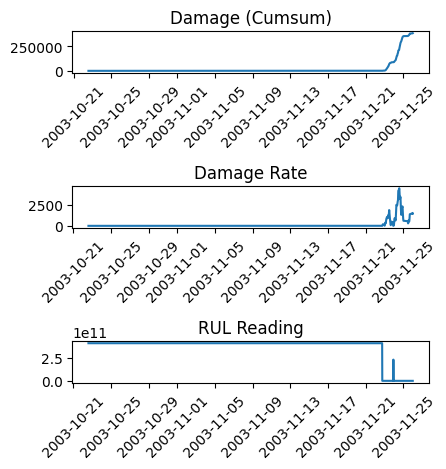

In [ ]:
# Ploting
damage_plot = plt.subplot2grid((3,3), (0,0), colspan=2)
damage_rate_plot = plt.subplot2grid((3,3), (1,0), colspan=2)
RUL_plot = plt.subplot2grid((3,3), (2,0), colspan=2)


# Can see it retains the previous bearing faults 
# Damage
damage_plot.plot(damage)
damage_plot.set_title("Damage (Cumsum)")
damage_plot.tick_params(axis="x", labelrotation=45)


# Damage Rate
damage_rate_plot.plot(damage_rate)
damage_rate_plot.set_title("Damage Rate")
damage_rate_plot.tick_params(axis="x", labelrotation=45)

# Rul
RUL_plot.plot(RUL_health_history)
RUL_plot.set_title("RUL Reading")
RUL_plot.tick_params(axis="x", labelrotation=45)

plt.tight_layout()
plt.show()


First burst (2003-11-22 17:36:56) with detected anomaly & onwards:
2003-11-24 05:01:24     96.799274
2003-11-24 05:11:24     82.952757
2003-11-24 05:21:24     72.884592
2003-11-24 05:31:24     64.680853
2003-11-24 05:41:24     58.382057
                          ...    
2003-11-25 16:07:32   -258.771705
2003-11-25 23:13:21   -242.505068
2003-11-25 23:19:56   -236.013424
2003-11-25 23:29:56   -240.582277
2003-11-25 23:39:56   -250.147021
Length: 133, dtype: float64


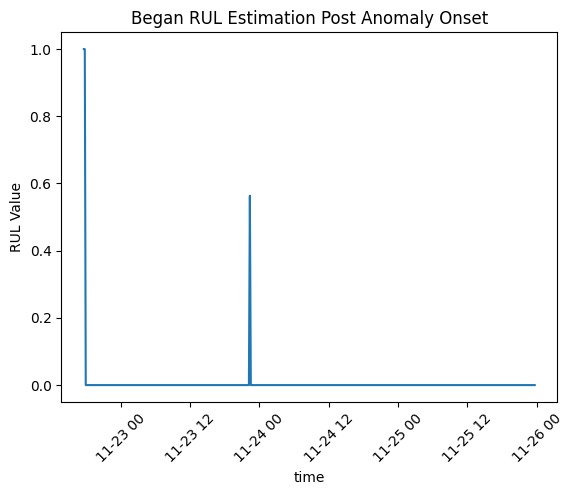

In [ ]:
RUL_Health_series = pd.Series(RUL_health_history)
RUL_post_onset = RUL_Health_series[first_abnormal_idx:]

print(f"First burst ({first_abnormal_idx}) with detected anomaly & onwards:\n{RUL_post_onset[RUL_Health_series < 100]}")


plt.plot(RUL_post_onset / RUL_post_onset.max())
plt.title("Began RUL Estimation Post Anomaly Onset")
plt.ylabel("RUL Value")
plt.xlabel("time")
plt.xticks(rotation=45)
plt.show()

NameError: name 'RUL' is not defined

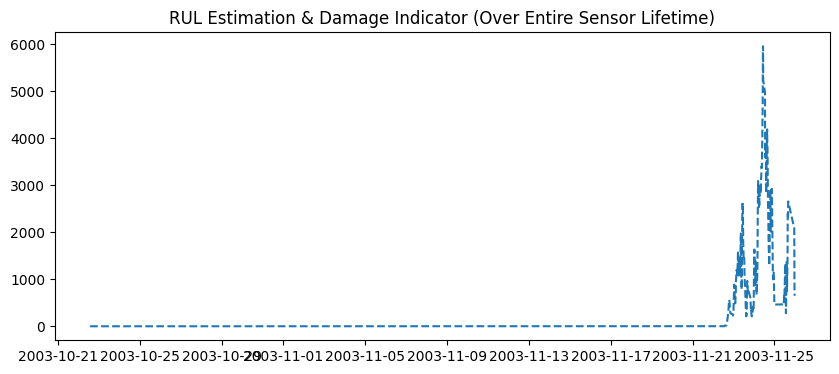

In [ ]:
import datetime

plt.figure(figsize=(10,4))
plt.title("RUL Estimation & Damage Indicator (Over Entire Sensor Lifetime)")
plt.plot(smoothed_error, label="Detected Damage", linestyle="--")
plt.plot((RUL / RUL.max())*10000, label="RUL")
plt.legend()
plt.show()

print(RUL_health[datetime.datetime.strptime("2004/02/17 11:00:00", "%Y/%m/%d %H:%M:%S"):])